#  Studying Higher-Harmonic Generation using RT-TDDFT  
**by <span style="color:darkgreen">Ronaldo Rodrigues Pela</span> for [<span style="color:darkgoldenrod">exciting *neon*</span>](https://www.exciting-code.org/neon)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Mara Voiculescu</span> and <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial, you will learn how to employ real-time time-dependent density-functional theory (**RT-TDDFT**) to study higher-harmonic generation. We consider two-dimensional MoS<sub>2</sub> to illustrate it.

<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Theoretical Background](#1)
    
[2. Ground-State Calculation](#2)
    
  - [Preparation of the Input File](#2)
  - [Running the Ground-State Calculation](#2.1)
    
[3. Performing the RT-TDDFT Calculations](#3)
    
  - [First Amplitude](#3)
  - [Running exciting](#3.1)
  - [Analyzing the Polarization](#3.1)
  - [Other Amplitudes](#3.2)

</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>


**<span style="color:firebrick">Important note:</span>** All input parameters that will appear will be given in **atomic units**! For this tutorial, it can be useful to remind the conversion between a.u. and the SI for times: 1 a.u. = 0.02418884254 fs.

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Theoretical Background</span>

Please refer to **[<span style="color:firebrick">Ref. [2]</span>](#4)** and the tutorial **Real-time TDDFT** for more details about **RT-TDDFT** in **`exciting`**.

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Ground-State Calculation</span>

**<span style="color:#15317E">i) Preparation of the Input File</span>**

The first step is to create a directory for the system that we want to investigate, **run_MoS2_hhg** and a subdirectory for the ground-state calculation, **GS**.

In [ ]:
%%bash
mkdir -p run_MoS2_hhg && cd run_MoS2_hhg
mkdir -p  GS
cd ..

As initial condition for the time evolution done in **RT-TDDFT**, we need the electron density and potential from a ground-state calculation. Therefore, we create the file **input.xml** that could look like the following:

<span class="MoS2_RT_TDDFT"></span>
```xml
<input>
 
   <title>MoS2</title>
 
   <structure speciespath="$EXCITINGROOT/species/">
      <crystal scale="6.0274">
         <basevect>  0.5  0.86602540378   0.0 </basevect>
         <basevect> -0.5  0.86602540378   0.0 </basevect>
         <basevect>  0.0  0.00000000000  10.0 </basevect>
      </crystal>
      <species speciesfile="Mo.xml" rmt="2.3">
         <atom coord="0.666667  0.666667  0.0"/>
      </species>
      <species speciesfile="S.xml"  rmt="2.05">
         <atom coord="0.333333  0.333333 -0.04938"/>
         <atom coord="0.333333  0.333333  0.04938"/>
      </species>
   </structure>
 
   <groundstate
      do="fromscratch"
      xctype="LDA_PW"
      ngridk="12 12 1"
      rgkmax="5.0d0"
      nempty="5"
      epsengy="1.d-8">
   </groundstate>
 
</input>
```

In [ ]:
from excitingjupyter.utilities import get_input_xml_from_notebook

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("studying_higher_harmonics_generation_using_rt_tddft", "MoS2_RT_TDDFT")

# Write out the input as an XML file:
with open('./run_MoS2_hhg/GS/input.xml', "w") as fid:
    fid.write(input_str)

Do not forget to replace in the **input.xml** the actual value of the environment variable **$EXCITINGROOT**. You can do this by directly editing the **input.xml** file or by using the following command:

In [ ]:
%%bash
cd run_MoS2_hhg/GS
python3 -m excitingscripts.setup.excitingroot
cd ../..

<a id='2.1'></a>
**<span style="color:#15317E">ii) Running the Ground-State Calculation</span>**

You can start the calculation by invoking the script **`excitingscripts.execute.single`**.

In [ ]:
%%bash
cd run_MoS2_hhg
python3 -m excitingscripts.execute.single -r GS
cd ..

You can check the output files, especially the main output file **INFO.OUT**, for general information. In the case of a successfully finished calculation, the last lines of the **INFO.OUT** will contain the message

```
...
================================================================================
| EXCITING NEON stopped                                                        =
================================================================================
```

Check if this is indeed the case and if the **EFERMI.OUT** and **STATE.OUT** files are present. They contain the **<span style="color:green">Fermi level</span>** and the converged **<span style="color:green">electron density and potential</span>**, respectively, and are the starting point of the **RT-TDDFT** calculation.

**<span style="color:firebrick">Please note</span>**: To obtain reliable results it is necessary to perform careful convergence tests with respect to the **k**-point mesh (parameter <code><span style="color:mediumblue">ngridk</span></code>) and the size of the basis set (parameter <code><span style="color:mediumblue">rgkmax</span></code>). For details see the tutorial **Simple convergence tests**.

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Performing the RT-TDDFT Calculations</span>

**<span style="color:#15317E">i) First Amplitude</span>**

Create a new subdirectory **ampl_1** and enter it. You can prepare the input file (**input.xml**) of a **RT-TDDFT** calculation starting from the existing groundstate input file. Copy the following files to the current directory. You can perform all of this with the following commands:

In [ ]:
%%bash
cd run_MoS2_hhg
mkdir -p ampl_1 && cd ampl_1
cp ../GS/{input.xml,EFERMI.OUT,STATE.OUT} .
cd ../..

The explicit ground-state calculation can be avoided with the attribute <code><span style="color:mediumblue">do</span>=<span style="color:firebrick">"skip"</span></code> inside the element <code><span style="color:green">groundstate</span></code>.

```xml
...
   <groundstate 
      do="skip"
      ... >
      ...
   </groundstate>
...

```
In order to perform a **"RT-TDDFT"** calculation, the element <code><span style="color:green">xs</span></code>, must be added to the input file inside the <code><span style="color:green">input</span></code> element, as shown below.

```xml
...
   <xs
      xstype="RT-TDDFT"
      ngridk="6 6 1"
      vkloff="0.01 0.02 0.004"
      nempty="5"
      nosym="true"
      reducek="false">
 
      <realTimeTDDFT
         propagator="AETRS"
         timeStep="0.5d0"
         endTime="200.d0">
         <laser fieldType="total">
            <sinSq amplitude="20.d0" omega="0.25d0" phase="0.d0"
               t0="0.1d0" pulseLength="160.d0" direction="x" />
         </laser>
         <pmat readFromFile="false" writeToFile="false" forceHermitian="false" />
      </realTimeTDDFT>
   </xs>
...

```

In [ ]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingXSInput

parsed_input = ExcitingInputXML.from_xml('./run_MoS2_hhg/ampl_1/input.xml')

xs = {'xstype': 'RT-TDDFT',
      'ngridk': [6, 6, 1],
      'vkloff': [0.01, 0.02, 0.004],
      'nempty': 5,
      'nosym': True,
      'reducek': False,
      'realTimeTDDFT': {'propagator': 'AETRS', 'timeStep': 0.5, 'endTime': 200.0,
                        'laser': {'fieldType': 'total', 'sinSq': [{'amplitude': 20.0, 'omega': 0.25, 'phase': 0.0, 
                                                                   't0': 0.1, 'pulseLength': 160.0, 
                                                                   'direction': 'x'}]},
                        'pmat': {'readFromFile': False, 'writeToFile': False, 'forceHermitian': False}}}

parsed_input.xs = ExcitingXSInput(**xs)
parsed_input.groundstate.do = "skip"

parsed_input.write('./run_MoS2_hhg/ampl_1/input.xml')

The element <code><span style="color:green">laser</span></code> describes the external field applied to the system. Here we consider a cosine modulated by a sin squared, as given in the element <code><span style="color:green">sinSq</span></code>. The expression for the corresponding vector potential is

\begin{equation}
\tag{1}
\mathbf{A}(t) = \mathbf{A}_0 f(t) \cos ( \omega t + \phi ),
\end{equation}

where $f(t)$, the envelope function, is given as

\begin{equation}
\tag{2}
f(t) = \left\{ \begin{array}{ll} 0 , & t \le t_0 \quad\mbox{ or }\quad t \ge t_0 + w \\ \sin^2( \pi(t-t_0)/w)\quad & t_0 \le t \le t_0 + w \\ \end{array} \right.
\end{equation}

The following figure illustrates the considered field

<figure>
<img src=" 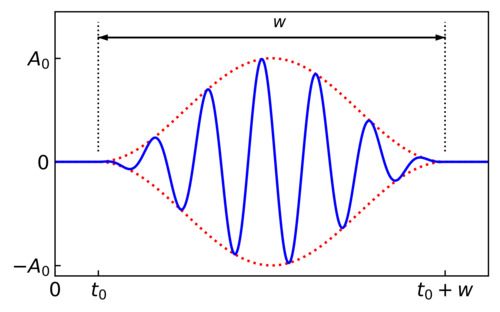" width="450" align="left"/>
</figure>

The parameter $w$ determines the width of the pulse, whereas $t_0$, the instant at which the pulse is applied.In our example, we consider a vector field along the x-direction (<code><span style="color:mediumblue">direction</span>=<span style="color:firebrick">"x"</span></code>) with an amplitude of 20 a.u. (<code><span style="color:mediumblue">amplitude</span>=<span style="color:firebrick">"20.d0"</span></code>). The cosine function has an angular frequency of $\omega = 0.25$ a.u. (<code><span style="color:mediumblue">omega</span>=<span style="color:firebrick">"0.25d0"</span></code>") and phase $\phi=0.0$ (<code><span style="color:mediumblue">phase</span>=<span style="color:firebrick">"0.d0"</span></code>). The envelope function has parameters: initial time $t_0=0.1$ a.u. and width of $w=160$ a.u. (as given by: <code><span style="color:mediumblue">t0</span>=<span style="color:firebrick">"0.1d0"</span></code>, <code><span style="color:mediumblue">pulseLength</span>=<span style="color:firebrick">"160.d0"</span></code>).
      
You can check all relevant parameters for a **"RT-TDDFT"** calculation in **[Input Reference](https://www.exciting-code.org/home/about/input-reference)**.

<a id='3.1'></a>
**<span style="color:#15317E">ii) Running exciting</span>**

Having modified the input file as described above, you can launch the **RT-TDDFT** calculation inside the subdirectory **ampl_1** using

In [ ]:
%%bash
cd run_MoS2_hhg
python3 -m excitingscripts.execute.single -r ampl_1
cd ..

Be aware that, depending on the computer you are using, this calculation may take several minutes.

**<span style="color:#15317E">iii) Analyzing the polarization</span>**

The time-evolution of the polarization vector $P(t)$ is printed out in the file **POLARIZATION_RTTDDFT.OUT**. With this file and **VECTOR_POTENTIAL.OUT**, we can inspect how the polarization of the system reacts to the applied electric field. To do so, we first obtain the electric field from **VECTOR_POTENTIAL.OUT**:

In [ ]:
%%bash
cd run_MoS2_hhg/ampl_1
python3 -m excitingscripts.plot.multitask --preprocess --get_efield -f VECTOR_POTENTIAL.OUT --x -o EFIELD.OUT
cd ../.. 

This command generates the output file **EFIELD.OUT** with the **x** component of the electric field, obtained from $A_x(t)$ in **VECTOR_POTENTIAL.OUT** **[<span style="color:firebrick">[3]</span>](#4)**.

To better compare the $P(t)$ and $E(t)$, it is advisable to scale the electric field by a factor of 1/10. This can be done with:

In [ ]:
%%bash
cd run_MoS2_hhg/ampl_1
python3 -m excitingscripts.plot.multitask --preprocess -f EFIELD.OUT --scale 1.0 0.1 -o EFIELD-SCALED.OUT
cd ../.. 

The previous command stores the scaled electric field in the file **EFIELD-SCALED.OUT**. Then, to plot $P(t)$ and the scaled electric field, $E(t)$/10:

In [ ]:
%%bash
cd run_MoS2_hhg/ampl_1
python3 -m excitingscripts.plot.multitask -f POLARIZATION_RTTDDFT.OUT EFIELD-SCALED.OUT -c '$P(t)$' '$E(t)/10$' --ylabel 'Field [a.u.]' --plot_name 'PLOT_01'
cd ../.. 

The resulting figure should look like

<figure>
<img src=" 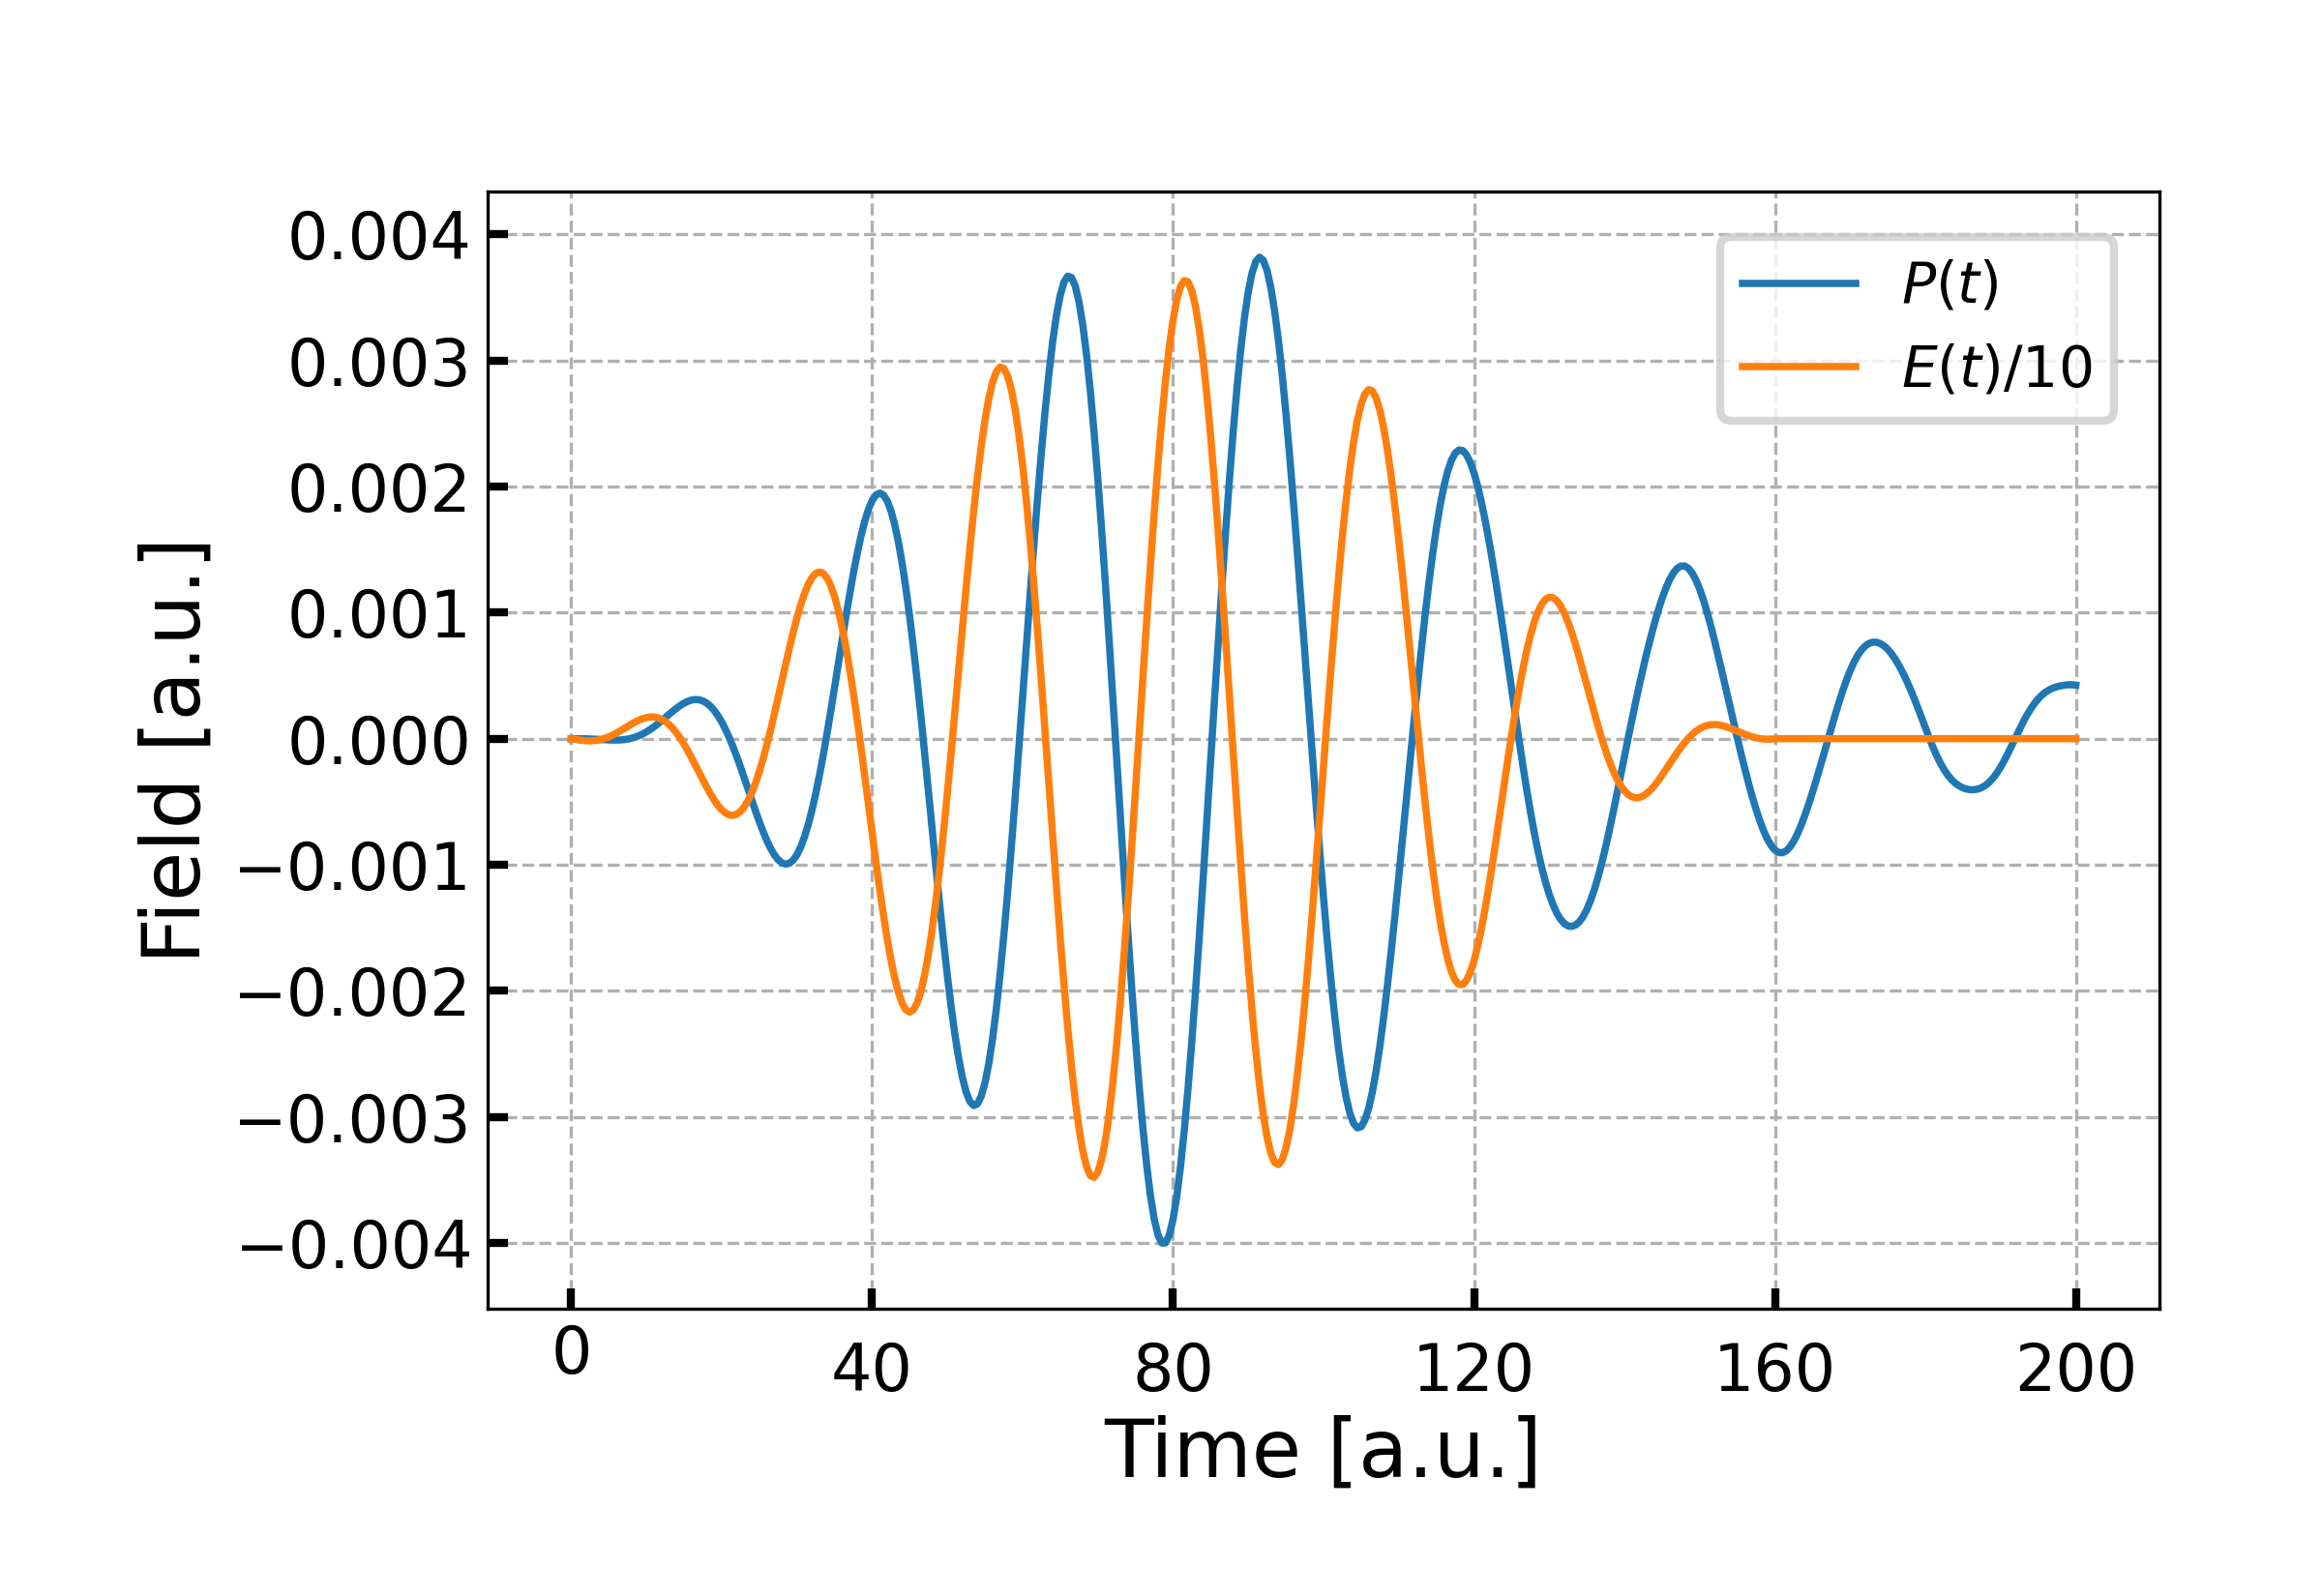" width="600" align="left"/>
</figure>

From the figure, although we see that there is a phase delay of almost 180° between $P(t)$ and $E(t)$, it is still not clear whether higher-harmonic components are present in $P(t)$. To verify it, we can employ the Fourier-Transform can help, which can be obtained through:

In [ ]:
%%bash
cd run_MoS2_hhg/ampl_1
python3 -m excitingscripts.plot.multitask --preprocess --fourier -f POLARIZATION_RTTDDFT.OUT -o P.OUT --wcut 0.025
cd ../.. 

In the previous command, we selected a broadening of $\eta$=0.025 a.u. This includes an exponential $\exp(-\eta t)$ in the definition of the Fourier Transform, in order to smooth it.

Before we plot the Fourier transform of $P(t)$, it is good to scale the angular frequencies $\omega$ with respect to 0.25 a.u. (the frequency of the applied laser), and also $P(t)$ with respect to the maximum of the electric field, $E_m$=0.03633 a.u. (see Note **[<span style="color:firebrick">[4]</span>](#4)**).

In [ ]:
%%bash
cd run_MoS2_hhg/ampl_1
python3 -m excitingscripts.plot.multitask --preprocess -f P.OUT --scale 4.0 27.52546105147261 --handle_complex abs -o P-SCALED.OUT
cd ../.. 

To plot the absolute value of the Fourier Transform in a semilog graph:

In [ ]:
%%bash
cd run_MoS2_hhg/ampl_1
python3 -m excitingscripts.plot.multitask -f P-SCALED.OUT --xlabel '$\omega/\omega_0$' --ylabel '$P(\omega)/E_m$' --xlim 0 7 --ylim 1e-5 1 --semilog --plot_name 'PLOT_02'
cd ../.. 

You should obtain a figure similar to the one below.

<figure>
<img src=" 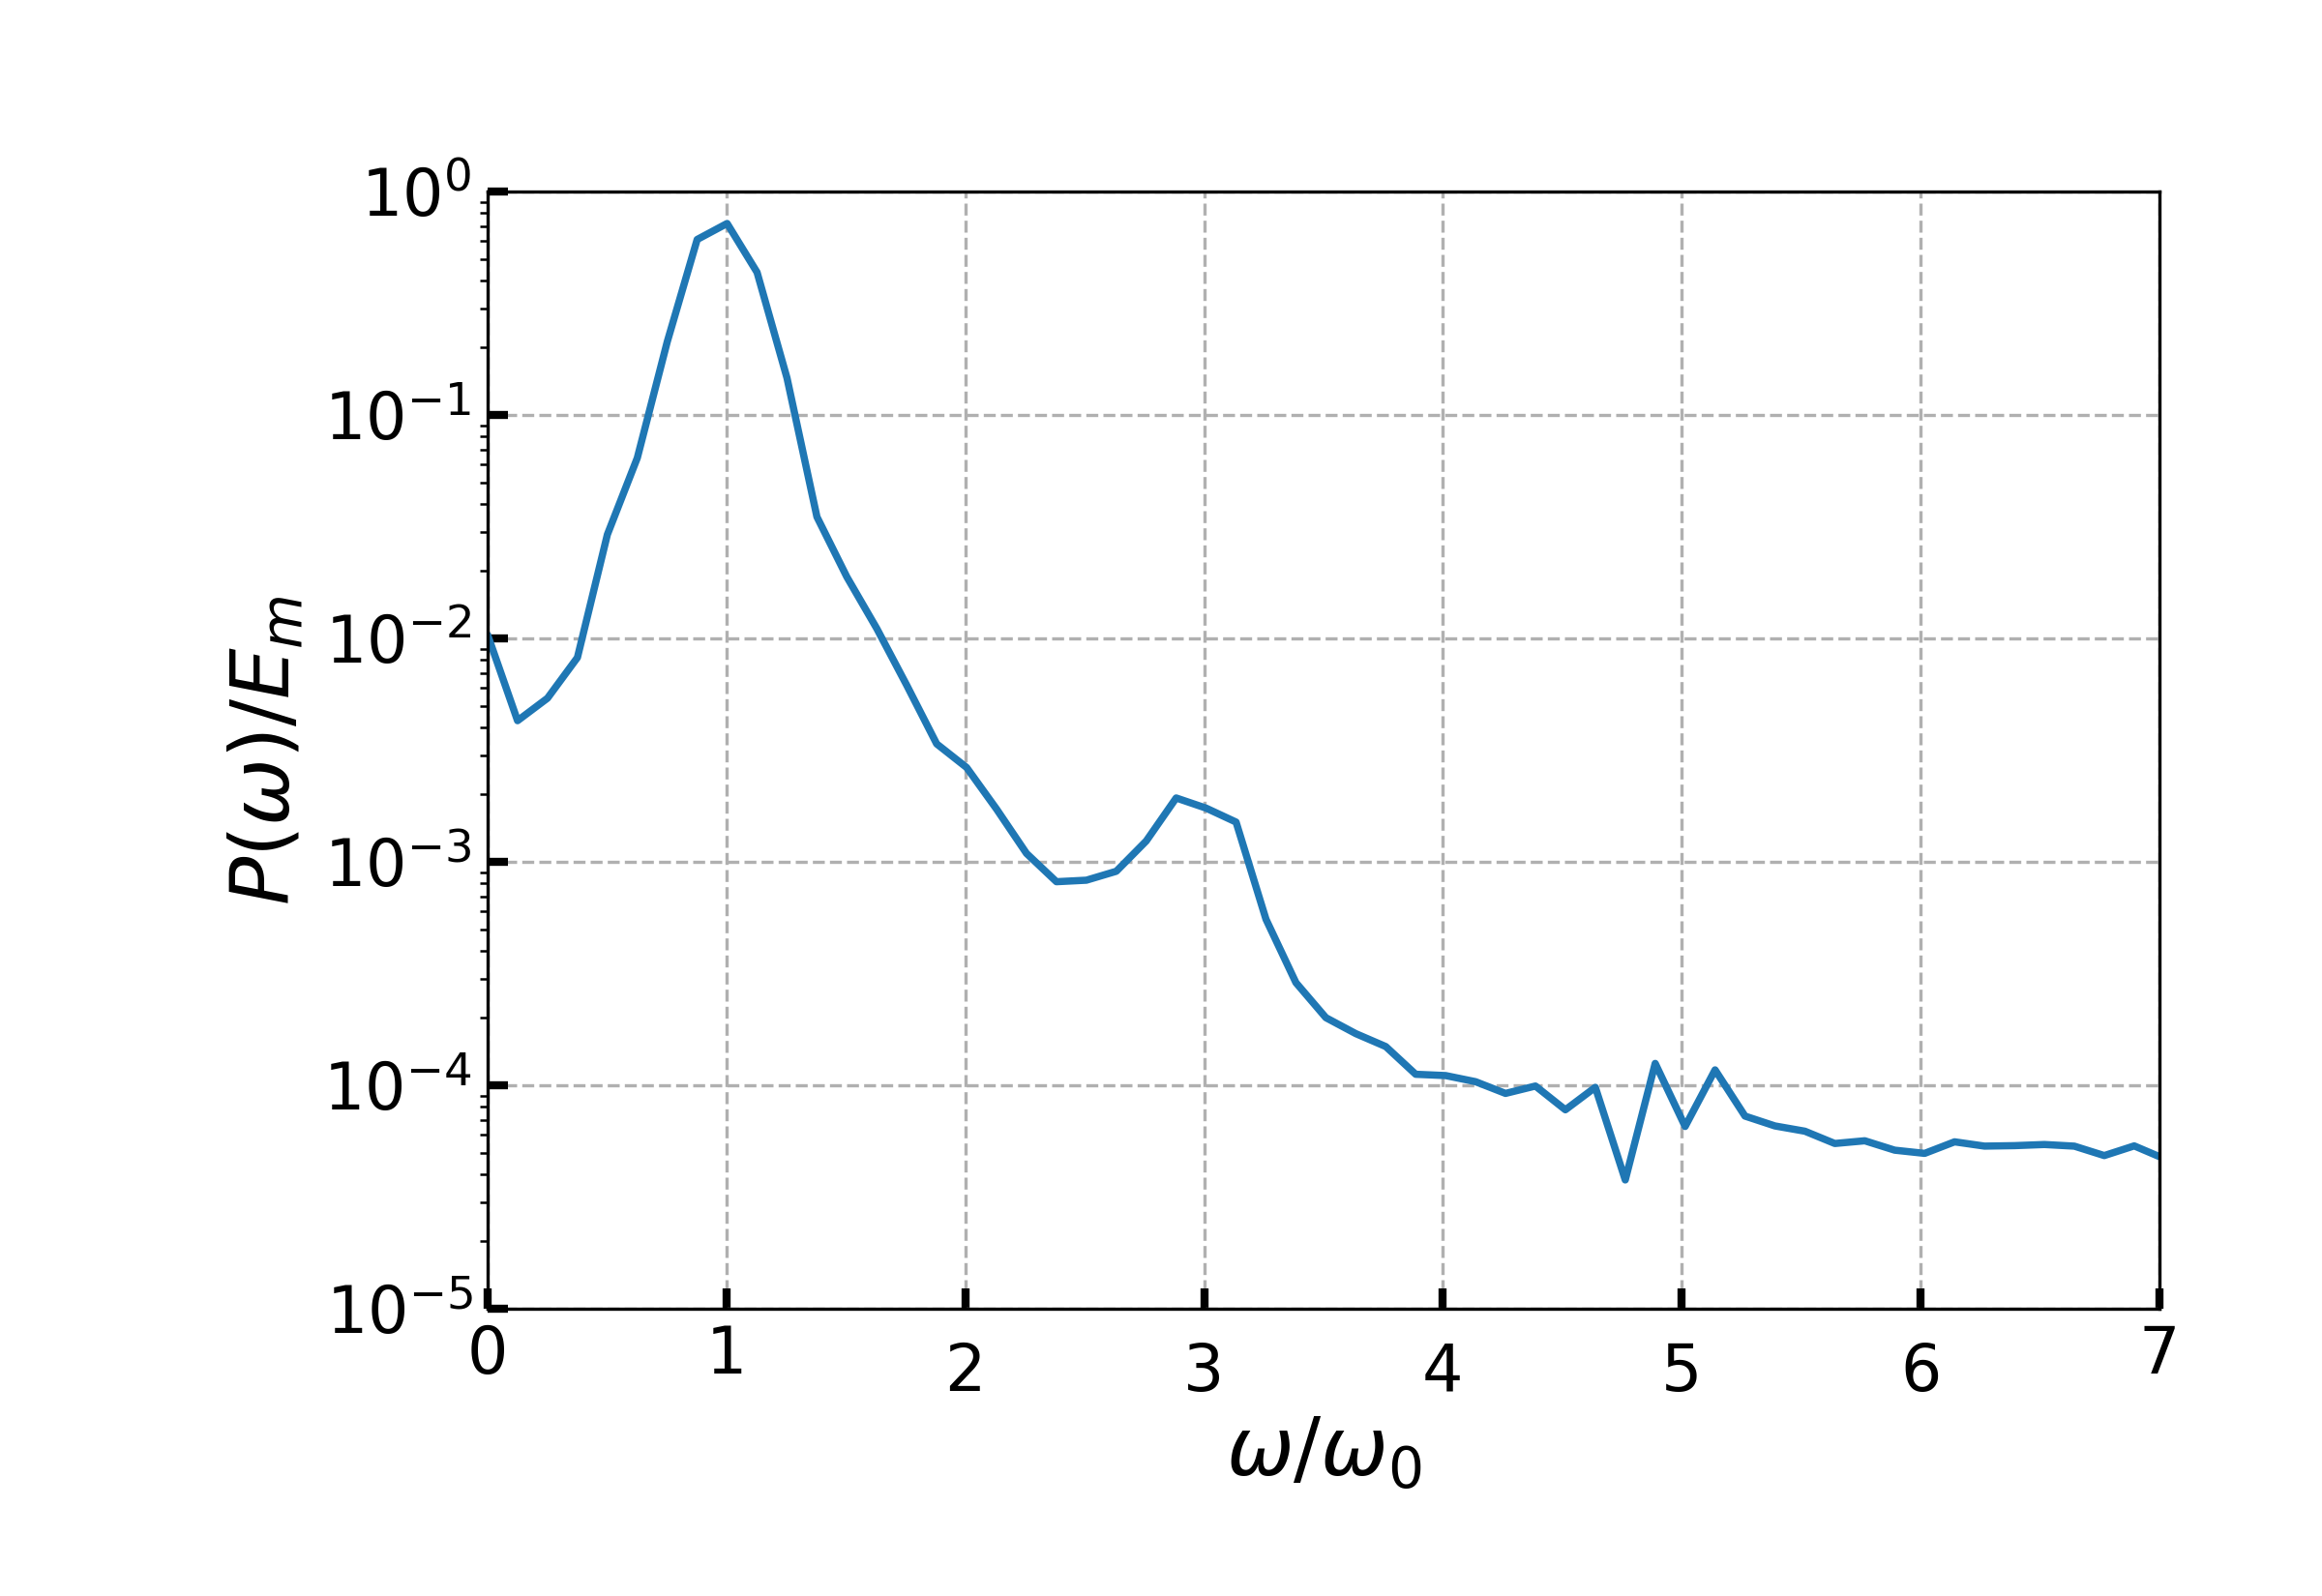" width="500" align="left"/>
</figure>

In this figure, $\omega$ is the usual variable employed for the frequency domain; and $\omega_0$ stands for the angular frequency of the electric field (here $\omega_0$=0.25 a.u.). Now, you can see a non-negligible component at $\omega/\omega_0$ = 3.

<a id='3.2'></a>
**<span style="color:#15317E">iv) Other Amplitudes</span>**

The amplitude considered in the previous calculation is rather high. It corresponds to an intensity of 4.6×10<sup>13</sup> W/cm<sup>2</sup> **[<span style="color:firebrick">[5]</span>](#4)**. As an exercise, you can run calculations for other amplitudes. You see in the next Figure that when the amplitude is reduced by a factor of 10 or 100, the third harmonic component almost practically disappears from the spectrum.

<figure>
<img src=" 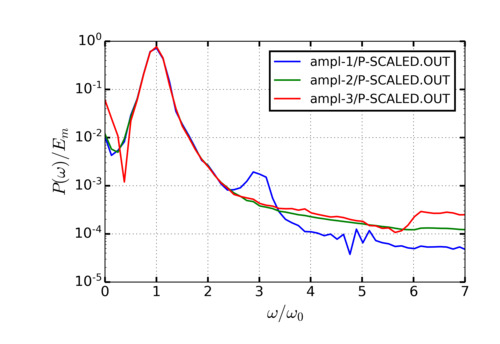" width="500" align="left"/>
</figure>

You can obtain this figure with the command

```bash
python3 -m excitingscripts.plot.multitask -f ampl-1/P-SCALED.OUT ampl-2/P-SCALED.OUT ampl-3/P-SCALED.OUT --xlabel '$\omega/\omega_0$' --ylabel '$P(\omega)/E_m$' --xlim 0 7 --ylim 1e-5 1 --semilog
```

Have in mind that you should follow the same procedure for the new amplitudes, obtaining for each of them **P-SCALED**. We assume that the calculations have been performed in the subfolders **ampl_1**, **ampl_2**, and **ampl_3**. In every of the subfolders, run the commands

```bash
python3 -m excitingscripts.plot.multitask --preprocess --fourier -f POLARIZATION_RTTDDFT.OUT -o P.OUT --wcut 0.025
```

```bash
python3 -m excitingscripts.plot.multitask --preprocess -f P.OUT --scale 4.0 27.52546105147261 --handle_complex abs -o P-SCALED.OUT
```

In folders **ampl_2** and **ampl_3** change the argument 27.52546105147261 in the second command above to 275.2546105147261 and 2752.546105147261, respectively, to have overlapping curves in the final plot. Then, you can use the previous command within the parent directory, **run_MoS2_hhg**.

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">Bibliography</span>

1. Here **hhg** stands for higher-harmonic generation.
2. Ronaldo Rodrigues Pela, Claudia Draxl. "All-electron full-potential implementation of real-time **TDDFT** in exciting" (**[link](https://iopscience.iop.org/article/10.1088/2516-1075/ac0c26)**).
3. More information about the script **`excitingscripts.plot.multitask`** can be found **[here](https://www.exciting-code.org/home/the-python-script-plot.multitask)**.
4. Note that dividing by **0.25** and **0.03633** is equivalent to multiplying by **4.0** and **27.52546105147261**, respectively, the given scaling factors within the command.
5. The intensity of an electromagnetic wave is

\begin{equation}
\tag{3}
I = \frac{1}{2}\varepsilon_0\, c\, E_m^2
\end{equation}

where $\varepsilon_0$ is the dielectric constant, $c$ is the speed of light, and $E_m$ is the peak-value of the electric field. Given $E_m$ in atomic units, $I$ is found in W/cm<sup>2</sup> with $(\varepsilon_0\, c)/2$ = 3.50941×10<sup>16</sup>. Please note that, due to reflections on the interface, $E_m$ inside the considered material is not the same as that produced by a laser. This also means that $I$ calculated using $E_m$ inside the material is not expected to match the intensity of the light generated by the laser, rather the intensity which penetrates the material.

<hr style="border:2px solid #DDD"> </hr>